___

> # **1. Motivation.**



<span style="color:red">

* What is your dataset?

* Why did you choose this/these particular dataset(s)?

* What was your goal for the end user's experience?
</span>.

***

> # **2. Basic stats.**

<span style="color:red">

* Write about your choices in data cleaning and preprocessing

* Write a short section that discusses the dataset stats, containing key points/plots from your exploratory data analysis.
</span>.

> ### **2.1.  Dataimport and preprocessing**

In [7]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
import folium
from folium.plugins import HeatMap
import re

In [8]:

shp = gpd.read_file("vejstoej_boliger_2022_udv/vejstoej_boliger_2022_udv.shp")
legeplads= gpd.read_file("legeplads/legeplads.shp")
daginstitutioner= gpd.read_file("daginstitutioner/daginstitutionerMPoint.shp")
grøn= gpd.read_file("park_groent_omr_oversigtskort/park_groent_omr_oversigtskort.shp") 

# Lokal fil
df_list_HC = pd.read_html("Aktuel luftkvalitet i Danmark.html")
df_list_jagtvej = pd.read_html("Aktuel luftkvalitet i Danmark jagtvej.html")
df_list_oersted = pd.read_html("Aktuel luftkvalitet i Danmark HCoersted.html")

def datetime(df_list):
    df= df_list[0]
    df["Målt (starttid)"] = pd.to_datetime(df["Målt (starttid)"], format="%d-%m-%Y %H:%M")
    df = df.sort_values("Målt (starttid)")
    df.set_index("Målt (starttid)", inplace=True)
    return df

df_HC=datetime(df_list_HC)
df_jagtvej=datetime(df_list_jagtvej)
df_oersted=datetime(df_list_oersted)


> ## **2.2 Data set stats and summary**

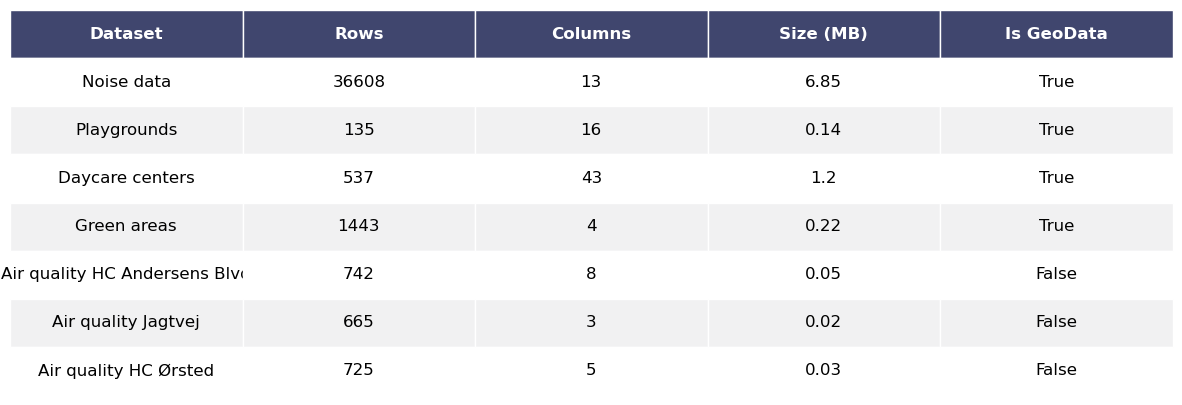

In [9]:
def dataset_summary(name, df):
    mem = df.memory_usage(deep=True).sum() / 1024**2
    return {
        "Navn": name,
        "Antal rækker": len(df),
        "Antal kolonner": df.shape[1],
        "Størrelse (MB)": round(mem, 2),
        "Geo-data": isinstance(df, gpd.GeoDataFrame)
    }

data = [
    dataset_summary("Støjdata", shp),
    dataset_summary("Legepladser", legeplads),
    dataset_summary("Daginstitutioner", daginstitutioner),
    dataset_summary("Grønne områder", grøn),
    dataset_summary("Luftkvalitet HC", df_list_HC[0]),
    dataset_summary("Luftkvalitet Jagtvej", df_list_jagtvej[0]),
    dataset_summary("Luftkvalitet Ørsted", df_list_oersted[0]),
]

summary_df = pd.DataFrame(data)
summary_df_english = summary_df.rename(columns={
    "Navn": "Dataset",
    "Antal rækker": "Rows",
    "Antal kolonner": "Columns",
    "Størrelse (MB)": "Size (MB)",
    "Geo-data": "Is GeoData"
})
summary_df_english['Dataset'] = summary_df_english['Dataset'].replace({
    "Støjdata": "Noise data",
    "Legepladser": "Playgrounds",
    "Daginstitutioner": "Daycare centers",
    "Grønne områder": "Green areas",
    "Luftkvalitet HC": "Air quality HC Andersens Blvd",
    "Luftkvalitet Jagtvej": "Air quality Jagtvej",
    "Luftkvalitet Ørsted": "Air quality HC Ørsted"
})
def render_mpl_table(data, col_width=3.0, row_height=0.625, font_size=12,
                     header_color='#40466e', row_colors=['#f1f1f2', 'w'],
                     edge_color='w', bbox=[0, 0, 1, 1], header_columns=0,
                     ax=None, **kwargs):
    if ax is None:
        size = (np.array(data.shape[::-1]) + np.array([0, 1])) * np.array([col_width, row_height])
        fig, ax = plt.subplots(figsize=size)
        ax.axis('off')

    mpl_table = ax.table(cellText=data.values, bbox=bbox, colLabels=data.columns, cellLoc='center', **kwargs)

    mpl_table.auto_set_font_size(False)
    mpl_table.set_fontsize(font_size)

    for k, cell in mpl_table._cells.items():
        cell.set_edgecolor(edge_color)
        if k[0] == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor(header_color)
        else:
            cell.set_facecolor(row_colors[k[0] % len(row_colors)])
    return ax

# Tegn tabellen
ax = render_mpl_table(summary_df_english, header_columns=0, col_width=3.0)
plt.savefig("summary_table.png", bbox_inches='tight', dpi=300)
plt.show()


___
> # **3. Data Analysis**

<span style="color:red">

* Describe your data analysis and explain what you've learned about the dataset.

* If relevant, talk about your machine-learning.

</span>.

In [10]:
def plot_luftforurening(df):
    # Make sure datetime is the index
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be a DatetimeIndex")

    # Get unique days for tick values (one per day)
    unique_days = df.index.normalize().unique()
    tickvals = unique_days
    ticktext = [d.strftime("%d-%b") for d in unique_days]

    # Only plot numeric columns
    numeric_cols = df.select_dtypes(include='number').columns

    # Plot
    fig = go.Figure()

    for col in numeric_cols:
        fig.add_trace(go.Scatter(
            x=df.index,
            y=df[col],
            mode='lines',
            name=col
        ))

    fig.update_layout(
        title="Tidsserie af luftforurening på H. C. Andersens Boulevard",
        xaxis_title="Dato",
        yaxis_title="Koncentration (μg/m³ eller tilsvarende)",
        xaxis=dict(
            tickvals=tickvals,
            ticktext=ticktext,
            tickangle=45,
            showgrid=True
        ),
        yaxis=dict(showgrid=True),
        legend=dict(title="Stof"),
        template="plotly_white",
        height=600,
        width=1000
    )

    fig.show()
plot_luftforurening(df_HC)
plot_luftforurening(df_jagtvej)
plot_luftforurening(df_oersted)

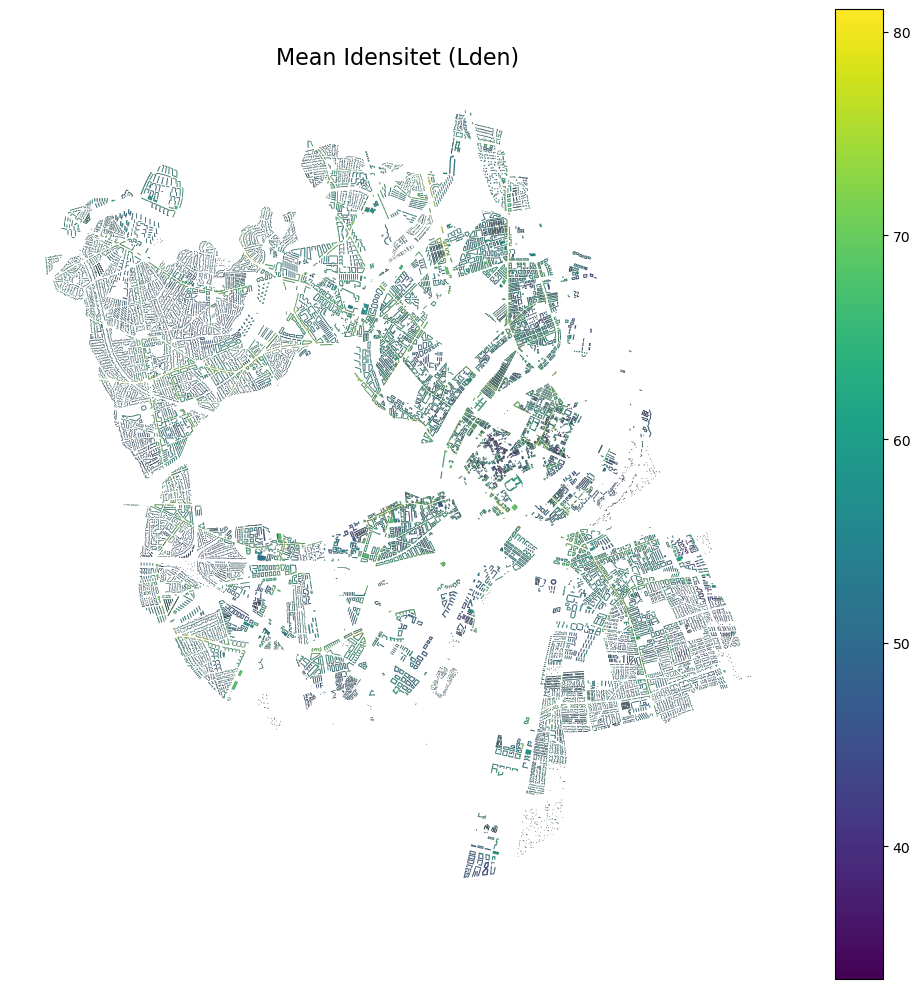

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
shp.plot(column='mean_lden',
         cmap='viridis',  # du kan også prøve 'plasma', 'coolwarm', osv.
         linewidth=0.1,
         edgecolor='black',
         legend=True,
         ax=ax)

ax.set_title("Mean Idensitet (Lden)", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import plotly.express as px

# Extract the first point from each geometry (assuming it's a MULTIPOINT with one coordinate)
legeplads['lon'] = legeplads.geometry.apply(lambda geom: geom.geoms[0].x)
legeplads['lat'] = legeplads.geometry.apply(lambda geom: geom.geoms[0].y)

# Create an interactive Plotly map
fig = px.scatter_mapbox(
    legeplads,
    lat='lat',
    lon='lon',
    hover_name='navn',  # Playground name
    hover_data=['adressebes', 'aldersgrup', 'graffitir0'],
    zoom=11,
    height=700
)
fig.update_traces(marker=dict(size=12))  # Try 12, 15, or higher for larger dots
fig.update_layout(mapbox_style='open-street-map')
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0}, title="Playgrounds in Copenhagen")

fig.show()
fig.write_image("playgrounds_map.png", scale=2)



In [13]:
import plotly.express as px

# Tæl antal institutioner pr. bydel
bydel_counts = daginstitutioner['bydel'].value_counts().reset_index()
bydel_counts.columns = ['City district', 'Number of institutions']

# Lav søjlediagram
fig = px.bar(bydel_counts,
             x='City district',
             y='Number of institutions',
             title='Number of institutions per city district in Copenhagen',
             labels={'City district': 'City district', 'Number of institutions': 'Number'},
             text='Number of institutions',
             height=700)

fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-45)

fig.show()

# Gem som billede (kræver kaleido installeret)
fig.write_image("daginst.png", scale=2)


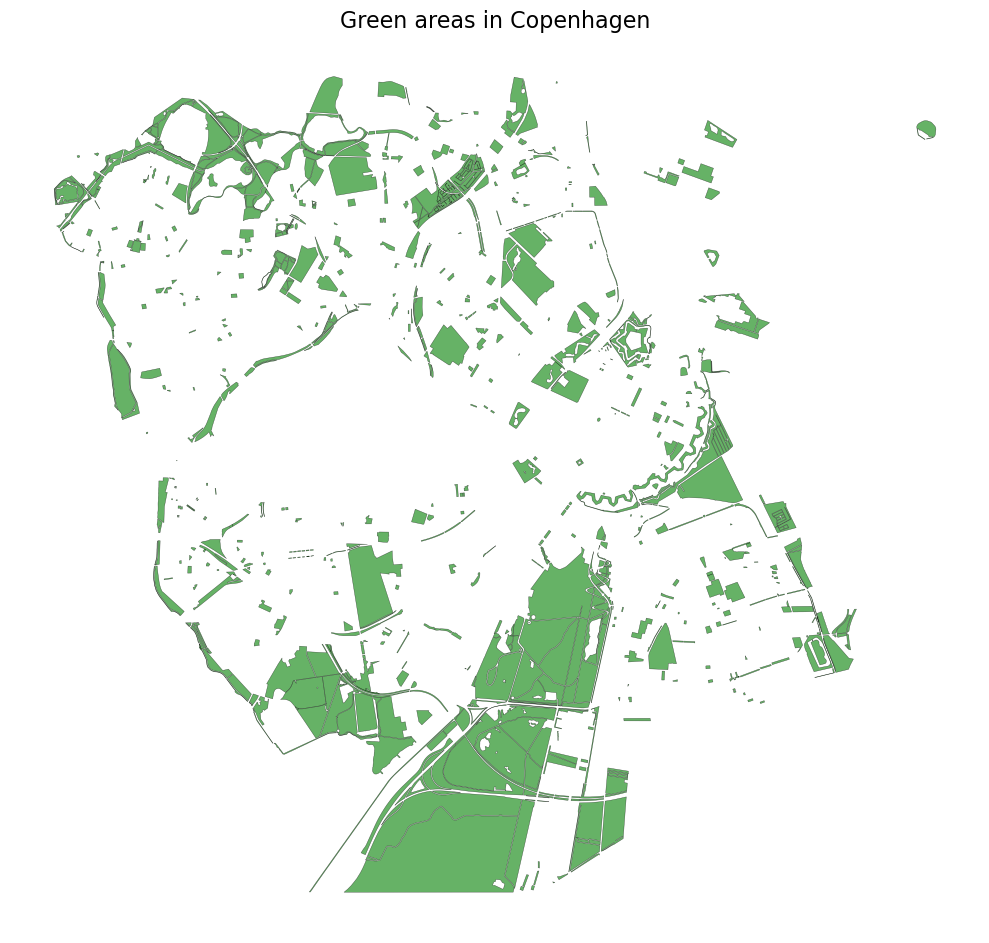

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Filtrér kun parker i Københavns Kommune (hvis ikke gjort)
grøn_kbh = grøn[grøn['kommune'] == 'København']

# Lav kort
fig, ax = plt.subplots(figsize=(10, 12))
grøn_kbh.plot(ax=ax, color='green', edgecolor='black', linewidth=0.3, alpha=0.6)

# Tilføj titel
ax.set_title('Green areas in Copenhagen', fontsize=16)

# Fjern akse
ax.set_axis_off()

plt.tight_layout()
plt.savefig('green_areas.png')
plt.show()



In [15]:
import geopandas as gpd
import folium

# URL of the GeoJSON data
url = "https://wfs-kbhkort.kk.dk/k101/ows?service=WFS&version=1.0.0&request=GetFeature&typeName=k101:miljozone&outputFormat=json&SRSNAME=EPSG:4326"

# Load the data into a GeoDataFrame
gdf = gpd.read_file(url)

# Get the center of Copenhagen
center = [55.6761, 12.5683]  # Latitude, Longitude of Copenhagen

# Create a folium map centered at Copenhagen
m = folium.Map(location=center, zoom_start=12)

# Add the environmental zone (miljozone) to the map
folium.GeoJson(gdf, name="Miljozone").add_to(m)

# Display the map
m

---

> # **4. Genre**




<span style="color:red">

* Which genre of data story did you use?

* Which tools did you use from each of the 3 categories of Visual Narrative (Figure 7 in Segal and Heer). Why?

* Which tools did you use from each of the 3 categories of Narrative Structure (Figure 7 in Segal and Heer). Why?

</span>.

___
> # **5. Visualizations**


<span style="color:red">

* Explain the visualizations you've chosen.

* Why are they right for the story you want to tell?

</span>.

___
> # **6. Discussion.**

<span style="color:red">

* Think critically about your creation

* What went well?,

* What is still missing? What could be improved?, Why?

</span>.

___
> # **7. Contributions.**

<span style="color:red">

* You should write (just briefly) which group member was the main responsible for which elements of the assignment. (I want you guys to understand every part of the assignment, but usually there is someone 

* who took lead role on certain portions of the work. That's what you should explain).

* It is not OK simply to write "All group members contributed equally".


</span>.



___
> # **8. Make sure that you use references when they're needed and follow academic standards.**